In [2]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ==========================================
# IMPORT THEO CẤU TRÚC MỚI (V3)
# ==========================================
from src.model_v2 import StockMovementModel
from src.data_loader_v6 import data_prepare, N_TICKERS
from configs.config import TrainConfig, GlobalConfig

# Import các hàm tiện ích từ main_v3.py
from main_v3 import StockDataset, merge_datasets, compute_class_weights, evaluate, EMASmoother

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(TrainConfig.seed)
device = torch.device("cuda" if TrainConfig.use_cuda and torch.cuda.is_available() else "cpu")

In [3]:
def load_all_data(pkl_path, price_mode="vol_adjusted", label_mode="rolling", include_ticker_id=True):
    print(f"Loading dataset from {pkl_path}...")
    # Cập nhật lời gọi data_prepare theo V6
    dp = data_prepare(
        pkl_path, 
        price_mode=price_mode, 
        label_mode=label_mode, 
        include_ticker_id=include_ticker_id
    )
    list_train, list_valid, list_test = [], [], []
    
    # Load tất cả ticker có trong config
    for ticker in GlobalConfig.TICKERS:
        try:
            tr, val, te = dp.prepare_data(ticker)
            if tr and len(tr.get("label", [])) > 0:
                list_train.append(tr)
                list_valid.append(val)
                list_test.append(te)
        except Exception:
            pass
            
    final_train = merge_datasets(list_train, shuffle=True)
    final_valid = merge_datasets(list_valid, shuffle=False)
    final_test  = merge_datasets(list_test,  shuffle=False)
    
    print(f"Total Train: {len(final_train['label'])}, Valid: {len(final_valid['label'])}, Test: {len(final_test['label'])}")
    return final_train, final_valid, final_test

# Tải dữ liệu
pkl_path = os.path.join(GlobalConfig.PROCESSED_PATH, "unified_dataset_test.pkl") 
train_data, valid_data, test_data = load_all_data(pkl_path)

Loading dataset from d:\ProjectNCKH\deep_finance\data\processed\unified_dataset_test.pkl...
Loaded dataset : 752 trading days
Price mode     : vol_adjusted
Label mode     : rolling
Ticker ID      : enabled
  TSLA: 752 days | news=752 (100%) | zero_emb=0 (0%)
  Labels  : {0: 245, 1: 234, 2: 259}
    train: N= 516  {0: 174, 1: 159, 2: 183}
    val  : N= 111  {0: 34, 1: 36, 2: 41}
    test : N= 111  {0: 37, 1: 39, 2: 35}
  TSLA: Train=516 Val=111 Test=111
  AAPL: 752 days | news=752 (100%) | zero_emb=0 (0%)
  Labels  : {0: 249, 1: 226, 2: 263}
    train: N= 516  {0: 175, 1: 161, 2: 180}
    val  : N= 111  {0: 38, 1: 32, 2: 41}
    test : N= 111  {0: 36, 1: 33, 2: 42}
  AAPL: Train=516 Val=111 Test=111
  AMZN: 752 days | news=752 (100%) | zero_emb=37 (5%)
  Labels  : {0: 240, 1: 237, 2: 261}
    train: N= 516  {0: 171, 1: 162, 2: 183}
    val  : N= 111  {0: 33, 1: 44, 2: 34}
    test : N= 111  {0: 36, 1: 31, 2: 44}
  AMZN: Train=516 Val=111 Test=111
  MSFT: 752 days | news=749 (100%) | zer

In [4]:
def tune_model(train_data, valid_data, test_data, custom_lr, custom_dim, epochs=30):
    """
    Hàm train rút gọn để lấy kết quả ACC, MCC cho việc vẽ biểu đồ.
    Đã bổ sung ticker_id và news_mask vào foward pass theo logic của main_v3.py
    """
    s_m_dim = train_data["s_m"].shape[-1]
    s_n_dim = train_data["s_n"].shape[-1]
    
    class_weights = compute_class_weights(train_data["label"]).to(device)
    train_loader = DataLoader(StockDataset(train_data), batch_size=getattr(TrainConfig, "batch_size", 32), shuffle=True)

    # Khởi tạo StockMovementModel V2
    model = StockMovementModel(
        price_dim=1, macro_dim=s_m_dim, news_dim=s_n_dim,
        dim=custom_dim,  # <-- Param thay đổi
        input_dim=TrainConfig.window_size,
        output_dim=3, num_head=TrainConfig.num_head,
        dropout=0.1, class_weights=class_weights,
        use_focal_loss=getattr(TrainConfig, "use_focal_loss", True),
        focal_gamma=getattr(TrainConfig, "focal_gamma", 2.0), 
        device=device,
        n_tickers=N_TICKERS # <-- Thêm số lượng ticker
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=custom_lr, # <-- Param thay đổi
        weight_decay=getattr(TrainConfig, "weight_decay", 1e-4)
    )
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=30, T_mult=2, eta_min=1e-6
    )

    smoother = EMASmoother(alpha=0.3, window=5)
    best_ema_mcc = -1.0
    best_test_acc, best_test_mcc = 0.0, 0.0

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            
            # Truyền đầy đủ args theo V3
            loss = model(
                batch["s_o"].to(device), 
                batch["s_h"].to(device), 
                batch["s_c"].to(device),
                batch["s_m"].to(device), 
                batch["s_n"].to(device), 
                batch["label"].to(device),
                mode="train",
                ticker_id=(batch["ticker_id"] if "ticker_id" in batch else None),
                news_mask=batch["news_mask"].to(device)
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        # Dùng hàm evaluate lấy trực tiếp từ main_v3 (đã xử lý P4)
        val_acc, val_mcc = evaluate(model, valid_data)
        ema_mcc = smoother.update(val_mcc)
        
        if ema_mcc > best_ema_mcc and epoch >= 9:
            best_ema_mcc = ema_mcc
            best_test_acc, best_test_mcc = evaluate(model, test_data)

    return best_test_acc, best_test_mcc

--- TUNING LEARNING RATE ---
Training with LR = 0.001...

  Class Weights:
    DOWN: count=875  weight=0.9897
    FLAT: count=776  weight=1.0484
    UP: count=929  weight=0.9618
  Loss: Focal Loss (γ=2.0)
  Fusion: Adaptive Gated MSGCA
    Stage 1: price (primary) × news  (P4: news_mask applied)
    Stage 2: price (primary) × macro (no mask)
Training with LR = 0.0005...

  Class Weights:
    DOWN: count=875  weight=0.9897
    FLAT: count=776  weight=1.0484
    UP: count=929  weight=0.9618
  Loss: Focal Loss (γ=2.0)
  Fusion: Adaptive Gated MSGCA
    Stage 1: price (primary) × news  (P4: news_mask applied)
    Stage 2: price (primary) × macro (no mask)
Training with LR = 0.0001...

  Class Weights:
    DOWN: count=875  weight=0.9897
    FLAT: count=776  weight=1.0484
    UP: count=929  weight=0.9618
  Loss: Focal Loss (γ=2.0)
  Fusion: Adaptive Gated MSGCA
    Stage 1: price (primary) × news  (P4: news_mask applied)
    Stage 2: price (primary) × macro (no mask)
Training with LR = 5e-05

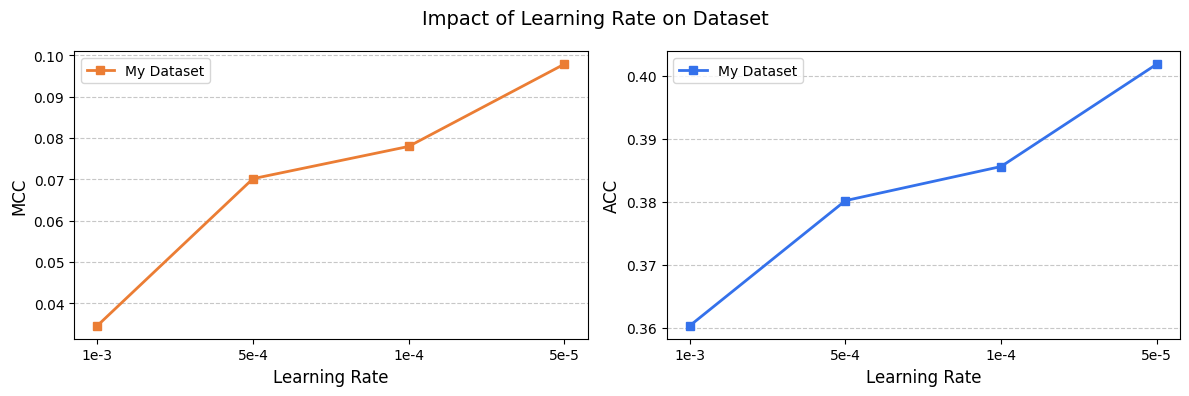

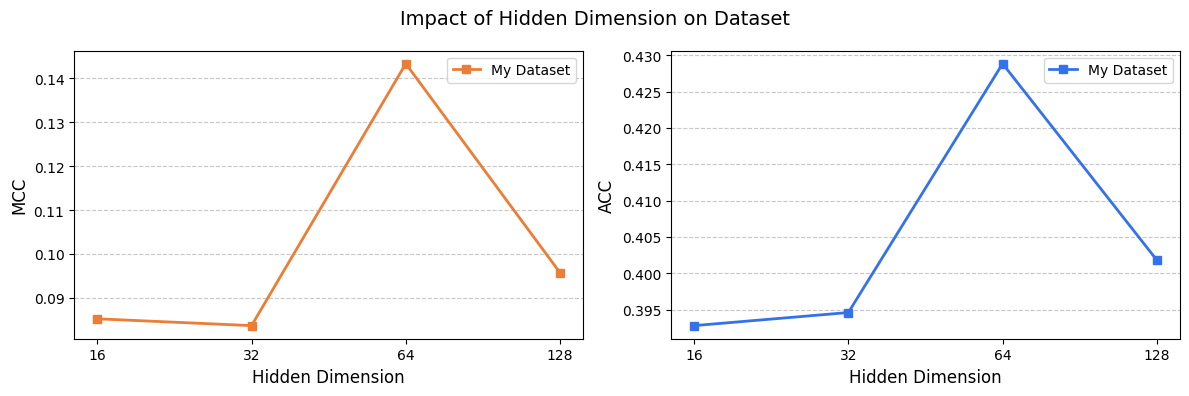

In [ ]:
# ==========================================
# 1. THỬ NGHIỆM TÁC ĐỘNG CỦA LEARNING RATE
# ==========================================
lr_list = [1e-3, 5e-4, 1e-4, 5e-5]
lr_labels = ['1e-3', '5e-4', '1e-4', '5e-5'] # String label để trục X đều nhau
lr_acc_results = []
lr_mcc_results = []
print("--- TUNING LEARNING RATE ---")
for lr in lr_list:
    print(f"Training with LR = {lr}...")
    # Fix dim=128 hoặc 64 tuỳ bạn
    set_seed(TrainConfig.seed)
    acc, mcc = tune_model(train_data, valid_data, test_data, custom_lr=lr, custom_dim=TrainConfig.dim, epochs=30) 
    lr_acc_results.append(acc)
    lr_mcc_results.append(mcc)

# ==========================================
# 2. THỬ NGHIỆM TÁC ĐỘNG CỦA HIDDEN DIMENSION
# ==========================================
dim_list = [16, 32, 64, 128]
dim_labels = ['16', '32', '64', '128']
dim_acc_results = []
dim_mcc_results = []

print("\n--- TUNING HIDDEN DIMENSION ---")
for d in dim_list:
    set_seed(TrainConfig.seed) # Khôi phục trạng thái
    print(f"Training with Dim = {d}...")
    # Fix lr = 1e-4
    acc, mcc = tune_model(train_data, valid_data, test_data, custom_lr=1e-4, custom_dim=d, epochs=30)
    dim_acc_results.append(acc)
    dim_mcc_results.append(mcc)


# ==========================================
# 3. VISUALIZE KẾT QUẢ (GIỐNG HÌNH BẠN GỬI)
# ==========================================
def plot_results(labels, acc_res, mcc_res, x_label, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Biểu đồ MCC
    axes[0].plot(labels, mcc_res, marker='s', linestyle='-', color='#eb7d34', linewidth=2, label='My Dataset')
    axes[0].set_xlabel(x_label, fontsize=12)
    axes[0].set_ylabel('MCC', fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].legend()

    # Biểu đồ ACC
    axes[1].plot(labels, acc_res, marker='s', linestyle='-', color='#3471eb', linewidth=2, label='My Dataset')
    axes[1].set_xlabel(x_label, fontsize=12)
    axes[1].set_ylabel('ACC', fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].legend()

    plt.suptitle(f'Impact of {title_prefix} on Dataset', fontsize=14)
    plt.tight_layout()
    plt.show()

# Vẽ 2 biểu đồ
plot_results(lr_labels, lr_acc_results, lr_mcc_results, x_label='Learning Rate', title_prefix='Learning Rate')
plot_results(dim_labels, dim_acc_results, dim_mcc_results, x_label='Hidden Dimension', title_prefix='Hidden Dimension')

In [ ]:
import pandas as pd # Thêm thư viện pandas để hiển thị bảng kết quả cho đẹp

# ==========================================
# THỰC HIỆN GRID SEARCH TÌM TỔ HỢP TỐI ƯU
# ==========================================
lr_list = [1e-3, 5e-4, 1e-4, 5e-5]
dim_list = [16, 32, 64, 128]

best_mcc = -1.0
best_acc = -1.0
best_combination = {'lr': None, 'dim': None}

# Lưu lại toàn bộ lịch sử để tiện theo dõi
grid_results = []

print("--- BẮT ĐẦU TÌM KIẾM GRID SEARCH (16 TỔ HỢP) ---")

for lr in lr_list:
    for d in dim_list:
        print(f"Đang huấn luyện: LR = {lr:<6} | Dim = {d:<3} ... ", end="")
        
        # BẮT BUỘC: Đặt lại seed để mọi mô hình đều xuất phát từ cùng một vạch đích
        set_seed(TrainConfig.seed)
        
        # Gọi hàm train (Lưu ý: tăng epochs lên 100 hoặc 150 nếu chạy thật để chốt kết quả)
        acc, mcc = tune_model(train_data, valid_data, test_data, custom_lr=lr, custom_dim=d, epochs=30)
        
        print(f"ACC: {acc:.4f} | MCC: {mcc:.4f}")
        
        # Lưu vào danh sách kết quả
        grid_results.append({'Learning Rate': lr, 'Hidden Dim': d, 'Test ACC': acc, 'Test MCC': mcc})
        
        # Cập nhật nếu tìm thấy kết quả tốt hơn
        if mcc > best_mcc:
            best_mcc = mcc
            best_acc = acc
            best_combination['lr'] = lr
            best_combination['dim'] = d

print("\n" + "="*60)
print(f">>> TỔ HỢP TỐI ƯU TUYỆT ĐỐI LÀ:")
print(f">>> LEARNING RATE = {best_combination['lr']} | HIDDEN DIMENSION = {best_combination['dim']}")
print(f">>> KẾT QUẢ ĐẠT ĐƯỢC: MCC = {best_mcc:.4f} | ACC = {best_acc:.4f}")
print("="*60)

# Hiển thị bảng tổng hợp để bạn dễ nhìn
df_results = pd.DataFrame(grid_results)
df_results = df_results.sort_values(by='Test MCC', ascending=False).reset_index(drop=True)
display(df_results)